In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, root_mean_squared_error

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [2]:
data = load_diabetes()

In [3]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
df = pd.DataFrame(data.data ,columns = data['feature_names'])

In [5]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


## Using Linear Regression

In [6]:
X = data.data
y = data.target

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 45)

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(X_test)

print("R2 score",r2_score(y_test, y_pred))
print("RMSE", root_mean_squared_error(y_test, y_pred))

R2 score 0.5188113124539246
RMSE 48.727137609532534


## Using Ridge Regression

## alpha = LAMBDA and also called Hyperparameter

In [26]:
ri = Ridge(0.0001)
ri.fit(X_train, y_train)

Ridge(alpha=0.0001)

In [27]:
y_pred1 = ri.predict(X_test)

print("R2 score", r2_score(y_test, y_pred1))
print("RMSE", root_mean_squared_error(y_test, y_pred1))

R2 score 0.5189732635884954
RMSE 48.71893700181953


## Generating Dataset

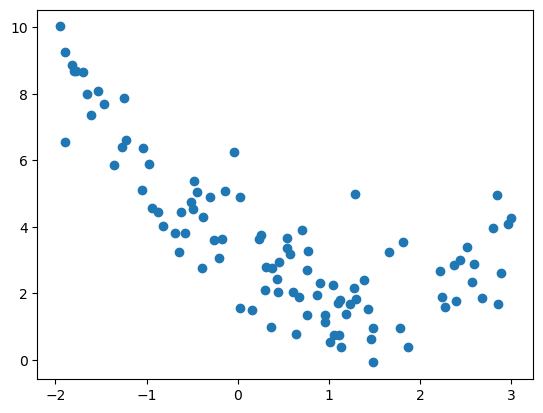

In [28]:
m = 100
x1 = 5 * np.random.rand(m, 1) -2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

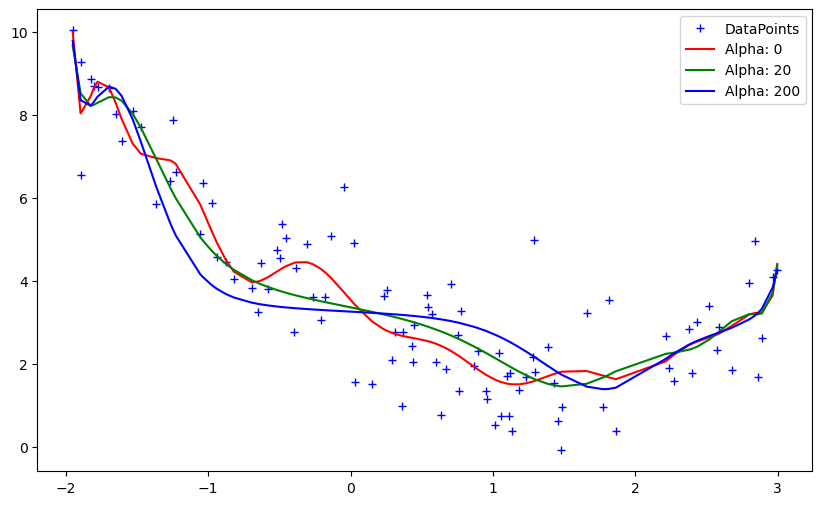

In [32]:
def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feature', PolynomialFeatures(degree = 16)),
        ('ridge', Ridge(alpha = alpha))
    ])

    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1, x2, 'b+', label = 'DataPoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1,x2, alpha)
    plt.plot(sorted(x1[:,0]), preds[np.argsort(x1[:,0])], c, label='Alpha: {}'.format(alpha))
    
plt.legend()
plt.show()